In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import great_tables
from great_tables import GT, md, html
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib import pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.factorplots import interaction_plot
from scipy.stats import levene
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [28]:
data =  pd.read_excel(r"Results_isofys\Numex_preliminar_base.xlsx") #work with the most updated and cleaned database
data = data.drop(columns = ["Unnamed: 0"])
data['Plot'] = data["Plot"].astype("category")
data['TreeID'] = data["TreeID"].astype("category")
#data['code'] = data["code"].astype("category")
data["Sub"] = data["Sub"].astype("category")
data["name"] = data["name"].astype("category")
data["Site"] = data["Site"].astype("category")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Plot                        180 non-null    category      
 1   TreeID                      180 non-null    category      
 2   Sub                         180 non-null    category      
 3   name                        180 non-null    category      
 4   genus                       180 non-null    object        
 5   specie                      180 non-null    object        
 6   Site                        180 non-null    category      
 7   [C_b]                       180 non-null    float64       
 8   bulk_δ13C (‰ v.s.V-PDB)     180 non-null    float64       
 9   [N]                         180 non-null    float64       
 10  δ15N (‰ v.s.AIR)            180 non-null    float64       
 11  [O]                         180 non-null    float64       

In [29]:
def table_summary(df):
    """This code do the last cleaning up of my database"""
    data = df
   # columskeep = []
    description = data.groupby(['name', 'Sub']).agg(["count","mean","std"]).round(2)
   # Get the name of the first numeric column
    first_numeric = data.select_dtypes("number").columns[0]
   # Keep only one 'count' column + all mean/std columns
    description = pd.concat([
    description.loc[:, (first_numeric, "count")],
    description.loc[:, pd.IndexSlice[:, ["mean", "std"]]]
       ], axis=1)
    description.to_excel("Summary.xlsx")
    print("Summary created and exported to Excel file")
    return description

table_summary(data)
#HELP homogeneize the name

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_3904\2062760336.py:5: FutureWarning: ['Plot', 'TreeID', 'genus', 'specie', 'Site', 'Sampling date'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  description = data.groupby(['name', 'Sub']).agg(["count","mean","std"]).round(2)


Summary created and exported to Excel file


[C_b]             bulk_δ13C (‰ v.s.V-PDB)        \
                            count  mean   std                    mean   std   
name                    Sub                                                   
Alchornea lojaensis     C      12  0.49  0.01                  -29.08  0.82   
                        N       9  0.49  0.01                  -29.40  0.99   
                        NP      8  0.48  0.03                  -29.45  1.51   
                        P      15  0.49  0.01                  -29.40  1.12   
Clarisia  racemosa      C       3  0.42  0.01                  -32.22  0.57   
                        N       1  0.45   NaN                  -32.98   NaN   
                        NP      4  0.43  0.01                  -32.12  0.51   
                        P       4  0.44  0.01                  -31.55  0.91   
Hedyosmun  purpurascens C       5  0.44  0.01                  -28.68  1.25   
                        N       6  0.43  0.01                  -27.78  1.22   
                        NP      3  0.44  0.01                  -26.99  1.20   
                        P       7  0.44  0.01                  -29.22  1.36   
Myrcia sp nov           C      15  0.47  0.01                  -31.27  0.97   
                        N      10  0.47  0.01                  -30.87  0.80   
                        NP     13  0.46  0.01                  -30.62  0.93   
                        P      11  0.47  0.01                  -30.82  0.52   
Pouteria torta          C      11  0.48  0.03                  -33.83  0.63   
                        N      10  0.48  0.01                  -33.24  1.10   
                        NP      7  0.48  0.01                  -33.98  1.34   
                        P       8  0.48  0.01                  -33.57  0.75   
Weinmania  loxensis     C       5  0.44  0.01                  -29.15  0.39   
                        N       5  0.45  0.01                  -29.30  0.80   
                        NP      2  0.46  0.01                  -30.08  0.44   
                        P       6  0.44  0.01                  -29.47  0.84   

                              [N]       δ15N (‰ v.s.AIR)         [O]  ...  \
                             mean   std             mean   std  mean  ...   
name                    Sub                                           ...   
Alchornea lojaensis     C    0.01  0.00            -5.27  1.16  0.47  ...   
                        N    0.01  0.00            -2.70  1.61  0.39  ...   
                        NP   0.01  0.00            -2.44  0.69  0.47  ...   
                        P    0.01  0.00            -5.08  0.96  0.45  ...   
Clarisia  racemosa      C    0.02  0.00             0.61  0.82  0.40  ...   
                        N    0.02   NaN             0.47   NaN  0.46  ...   
                        NP   0.02  0.00             2.04  0.62  0.46  ...   
                        P    0.02  0.00             0.60  0.51  0.48  ...   
Hedyosmun  purpurascens C    0.01  0.00            -2.58  2.62  0.45  ...   
                        N    0.02  0.00            -1.13  1.59  0.45  ...   
                        NP   0.02  0.00            -0.77  0.64  0.44  ...   
                        P    0.02  0.00            -1.42  1.60  0.45  ...   
Myrcia sp nov           C    0.01  0.01            -3.58  1.98  0.50  ...   
                        N    0.01  0.00            -2.79  0.43  0.45  ...   
                        NP   0.01  0.00            -1.64  0.76  0.47  ...   
                        P    0.01  0.00            -4.60  0.84  0.48  ...   
Pouteria torta          C    0.02  0.00             1.28  0.85  0.50  ...   
                        N    0.02  0.00             1.49  1.06  0.49  ...   
                        NP   0.02  0.00             1.79  0.92  0.48  ...   
                        P    0.02  0.00             1.01  0.76  0.49  ...   
Weinmania  loxensis     C    0.01  0.00            -4.45  2.16  0.46  ...   
                        N    0.01  0.00       

In [30]:
data.to_excel("data_for_R.xlsx")

### Variables included in the database
### variables fisiologicas
- vp1 = "iWUE (μmol/mol)"
- vp2 = "δ15N (‰ v.s.AIR)"
- vp3 = "△13C_cell"
- vp3 = "δ13C (‰ v.s.V-PDB)" #cellulose
- vp4 = "δ18O in ‰ vs DeltaSMOW" #cellulose
- vp5 =  "[O]"
- vp6 = "[C]%" #celulosa
- vp7 = "13dC/18dO"
- vp8 = "Ci/Ca"
- vp9 = "Ci"

### bulk ####
- vb1 = "[N]"
- vb2 = "[C_b]" #bulk
- vb3 = "bulk_δ13C (‰ v.s.V-PDB)"
- vb4 = "C:N"

### morfo rasgo ###

- vf1 = "force to punch (kN/m)"#"mean toughness (kN/m)"
- vf2 = "thickness (mm)"#mean thickness (mm)"
- vf3 = "dry matter content (mg/g)"#"#names for publication.py"
- vf5 = "height_2024"
- vf6 = "Leaf area (cm²)"
- vf7 = "Specific leaf area (g/cm²)"
- vf8 =  "area_basal_m2"

#var = vp2 #### aqui definimos para analizar en todos los siguientes

In [31]:
import config
from config import * #Here we use the standarized variables names for easines

var = name18O #### aqui definimos para analizar en todos los siguientes

### Overall pairplot 
Here are all the included traits. SF is not complete


In [ ]:
iWUE = "iWUE (μmol/mol)"
columns = [iWUE,thick,though,LA,SLA,leaf_water]

# I want to see the iWUE agains the functional traits 
#sns.pairplot(
#    data=data,
#    vars=columns, 
#    hue = "elevation_m",  
#    #kind = "reg",
#    corner = True
#)
#plt.tight_layout()
#plt.show()



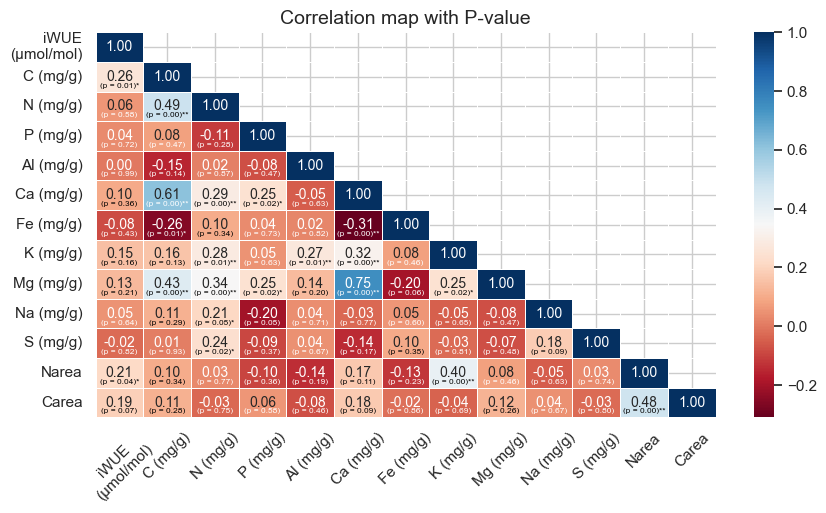

In [33]:
SF = data[data["Site"]=="SFNu"] #I want to see the relationship with nutrients. #HELP: Treatments not analyzed.
columnas = [iWUE, "C (mg/g)","N (mg/g)","P (mg/g)","Al (mg/g)","Ca (mg/g)","Fe (mg/g)","K (mg/g)","Mg (mg/g)","Na (mg/g)","S (mg/g)","Narea","Carea"]
df = SF[columnas] # most import to have the df clean only with numeric for the correlation maps.

def corr_pvalue(df):
 
 import textwrap
 from scipy.stats import pearsonr
 from scipy.stats import spearmanr
 from scipy.stats import kendalltau
 import numpy as np
 # Generate the correlation matrix afresh
 corr = df.corr(numeric_only=True)

 # mask the correlation matrix to diagonal
 mask = np.zeros_like(corr, dtype=bool)
 mask[np.triu_indices_from(mask)] = True
 np.fill_diagonal(mask, False)

 fix,ax = plt.subplots(figsize=(10,5))
 plt.title("Correlation map with P-value", fontsize=14)

 # Generate heatmap
 heatmap = sns.heatmap(corr,
                      annot= True,
                      annot_kws={"fontsize": 10},
                      fmt='.2f',
                      linewidths=0.5,
                      cmap='RdBu',
                      mask=mask,
                      ax=ax)

 # calculate and format p-values
 p_values = np.full((corr.shape[0], corr.shape[1]), np.nan)
 for i in range(corr.shape[0]):
  for j in range(i+1, corr.shape[1]):
    x = df.iloc[:, i]
    y = df.iloc[:, j]
    mask = ~np.logical_or(np.isnan(x), np.isnan(y))
    if np.sum(mask) > 0:
      p_values[i, j] = pearsonr(x[mask], y[mask])[1] #change to pearsonr or spearmanr, kendalltau

 # Create a dataframe object for p_values
 p_values = pd.DataFrame(p_values, columns=corr.columns, index=corr.index)

 # Mask the p values
 mask_pvalues = np.triu(np.ones_like(p_values), k=1)

 # Generate maximum and minimum correlation coefficients for p-value annotation color
 max_corr = np.max(corr.max())
 min_corr = np.min(corr.min())

 # Assign p-value annotations, include asterisks for significance
 for i in range (p_values.shape[0]):
  for j in range(p_values.shape[1]):
    if mask_pvalues[i, j]:
      p_value = p_values.iloc[i, j]
      if not np.isnan(p_value):
        correlation_value = corr.iloc[i, j]
        text_color = 'white' if correlation_value >= (max_corr - 0.4) or correlation_value <= (min_corr + 0.4) else 'black'
        if p_value <= 0.01:
            #include double asterisks for p-value <= 0.01
            ax.text(i + 0.5, j + 0.8, f'(p = {p_value:.2f})**',
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=6,
                    color=text_color)
        elif p_value <= 0.05:
            #include single asterisk for p-value <= 0.05
            ax.text(i + 0.5, j + 0.8, f'(p = {p_value:.2f})*',
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=6,
                    color=text_color)
        else:
            ax.text(i + 0.5, j + 0.8, f'(p = {p_value:.2f})',
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=6,
                    color=text_color)

 # Customize x-axis labels
 x_labels = [textwrap.fill(label.get_text(), 13) for label in ax.get_xticklabels()]
 ax.set_xticklabels(x_labels, rotation=45, ha="center")

 # Customize y-axis labels
 y_labels = [textwrap.fill(label.get_text(), 13) for label in ax.get_yticklabels()]
 ax.set_yticklabels(y_labels, rotation=0, ha="right")

 # Display the plot
 return plt.show()

corr_pvalue(df)

In [34]:
print(data.columns)

Index(['Plot', 'TreeID', 'Sub', 'name', 'genus', 'specie', 'Site', '[C_b]',
       'bulk_δ13C (‰ v.s.V-PDB)', '[N]', 'δ15N (‰ v.s.AIR)', '[O]',
       'δ18O in ‰ vs DeltaSMOW', '[C]', 'δ13C (‰ v.s.V-PDB)', 'height_2024',
       'force to punch (kN/m)', 'thickness (mm)', 'Leaf fresh weight (g)',
       'Leaf dry weight (g)', 'Leaf area (cm²)', 'area_basal_m2',
       'Sampling date', 'sample-ID', 'number of leaves',
       'dry matter content (mg/g)', 'C (mg/g)', 'N (mg/g)', 'P (mg/g)',
       'Al (mg/g)', 'Ca (mg/g)', 'Fe (mg/g)', 'K (mg/g)', 'Mg (mg/g)',
       'Na (mg/g)', 'S (mg/g)', '△13C_cell', 'Ci', 'Ci/Ca', 'iWUE (μmol/mol)',
       'annual_precipitation_mm', 'elevation_m', 'mean_annual_temperature_C',
       'WD', 'Specific leaf area (g/cm²)', 'leaf water content', 'C:N',
       '13dC/18dO', 'Narea', 'Carea'],
      dtype='object')


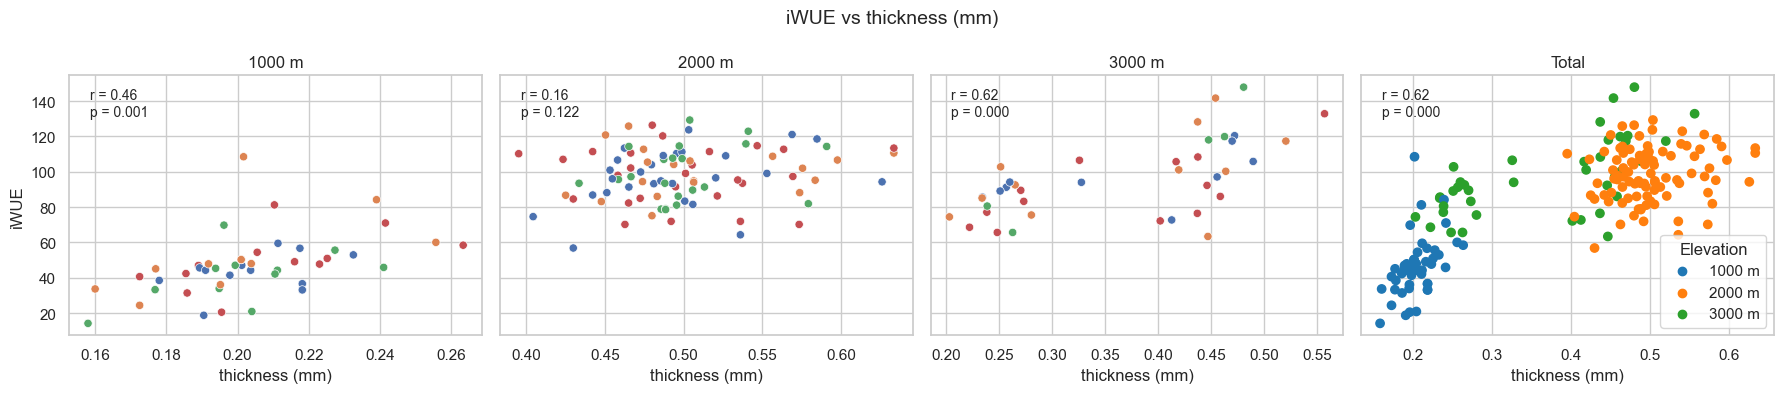

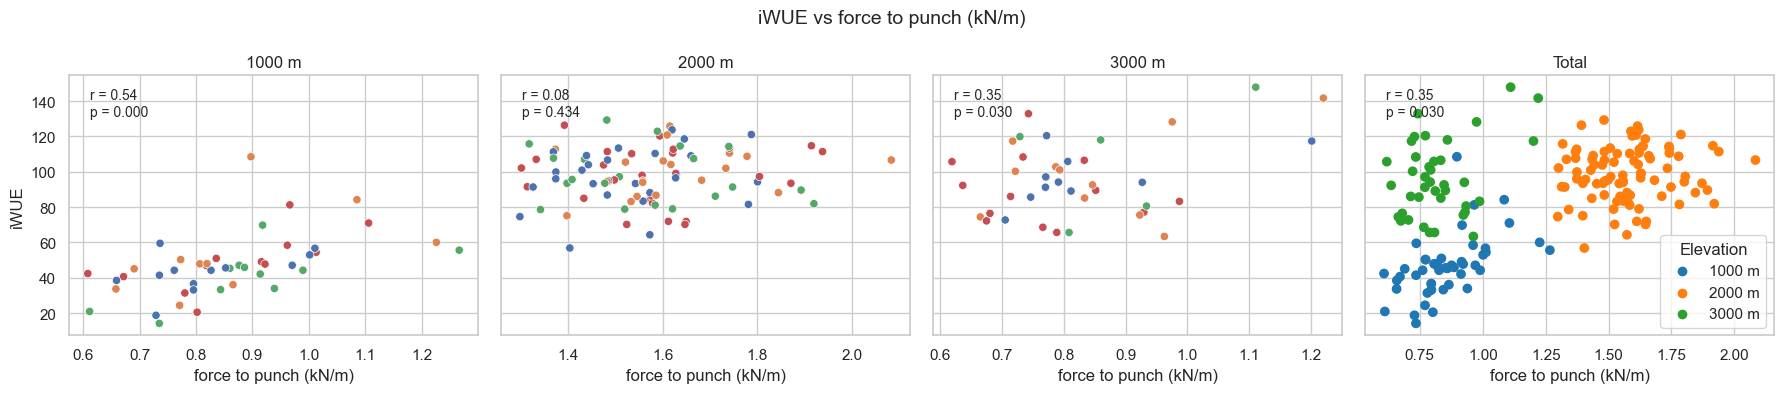

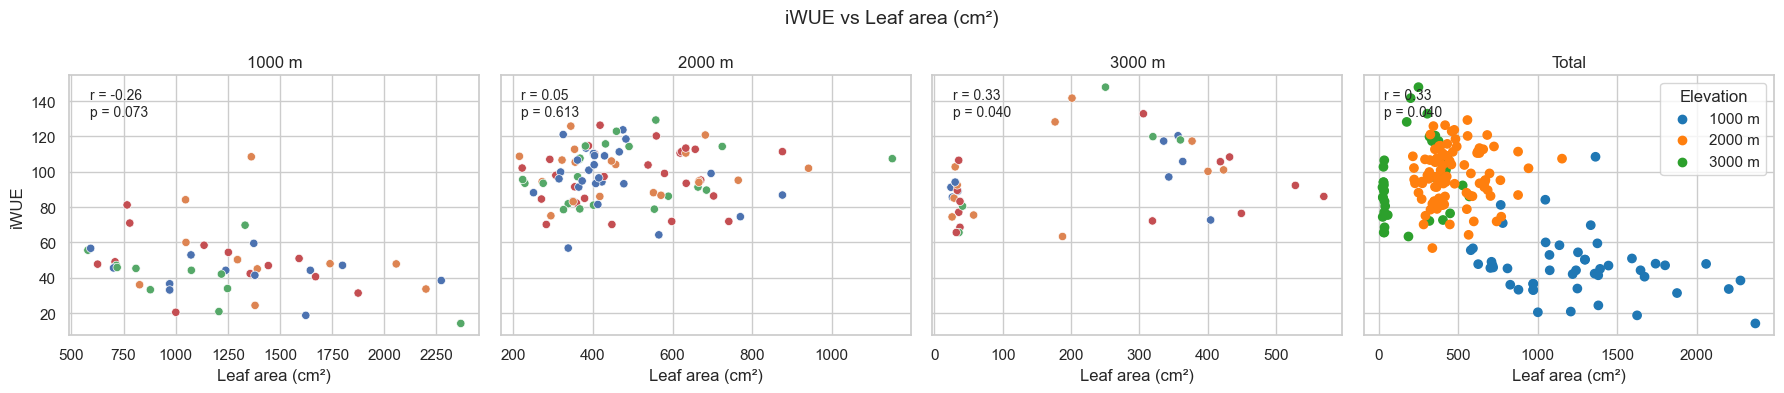

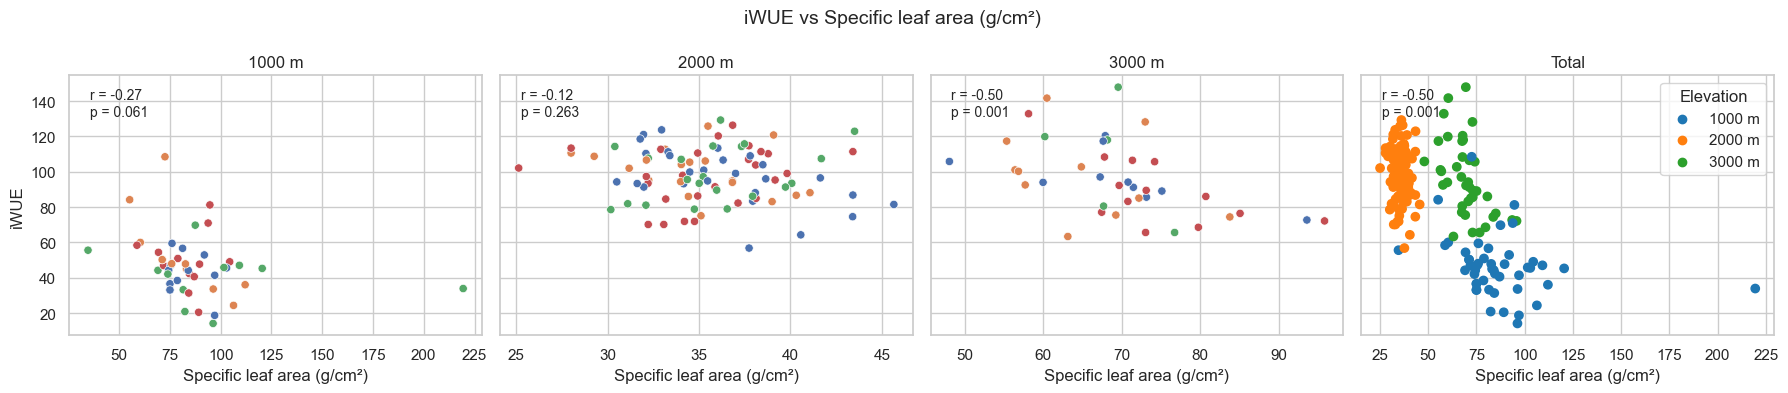

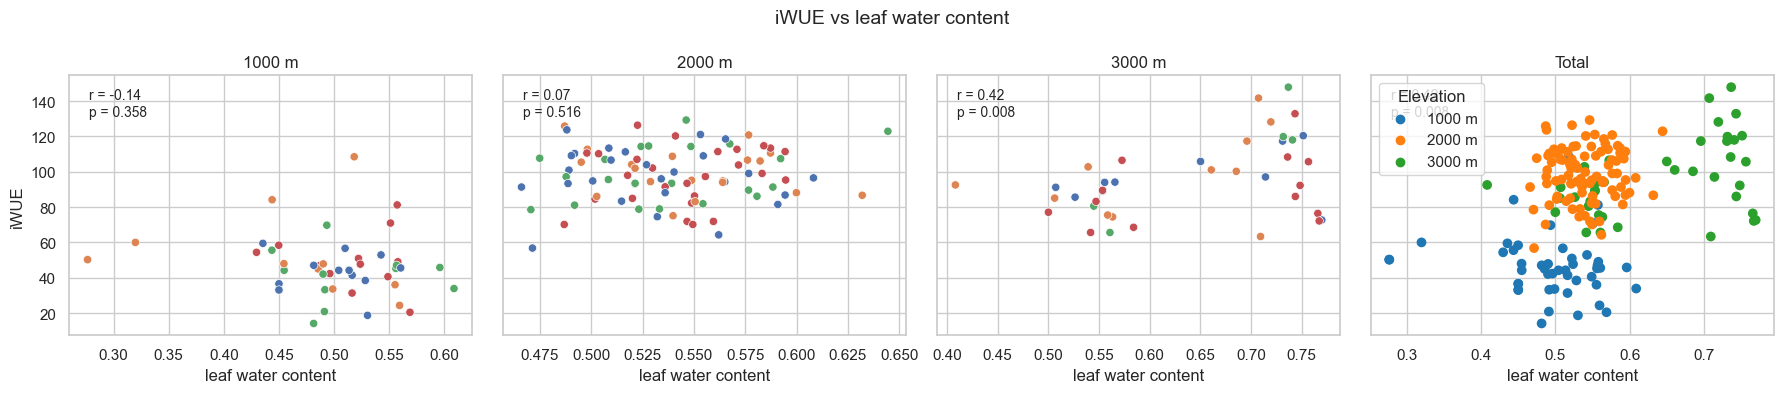

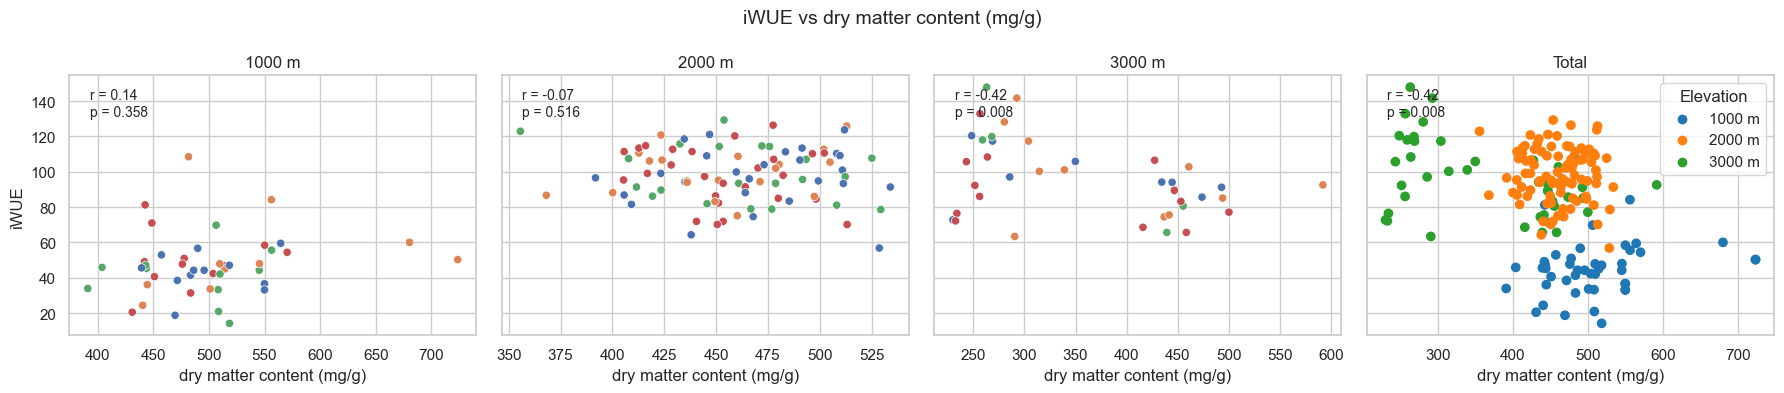

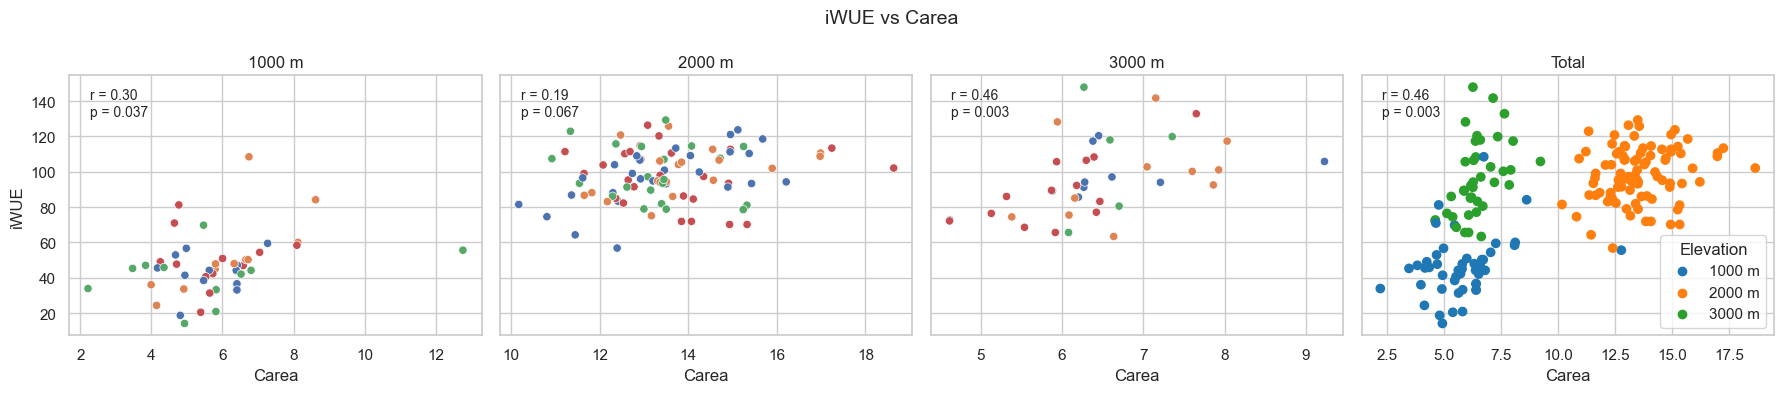

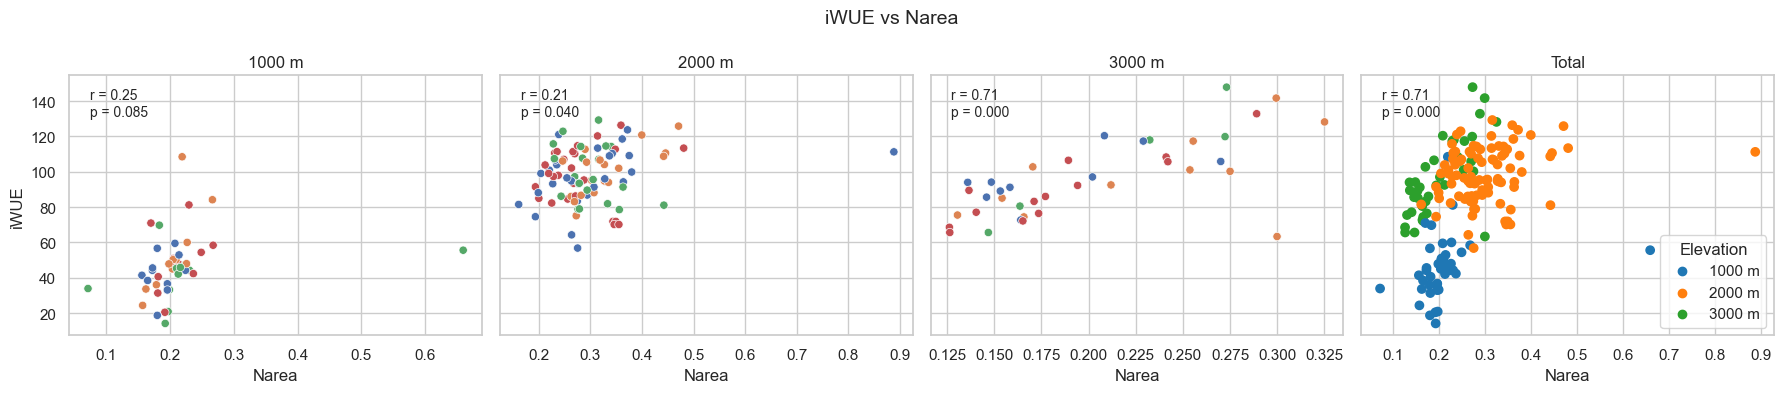

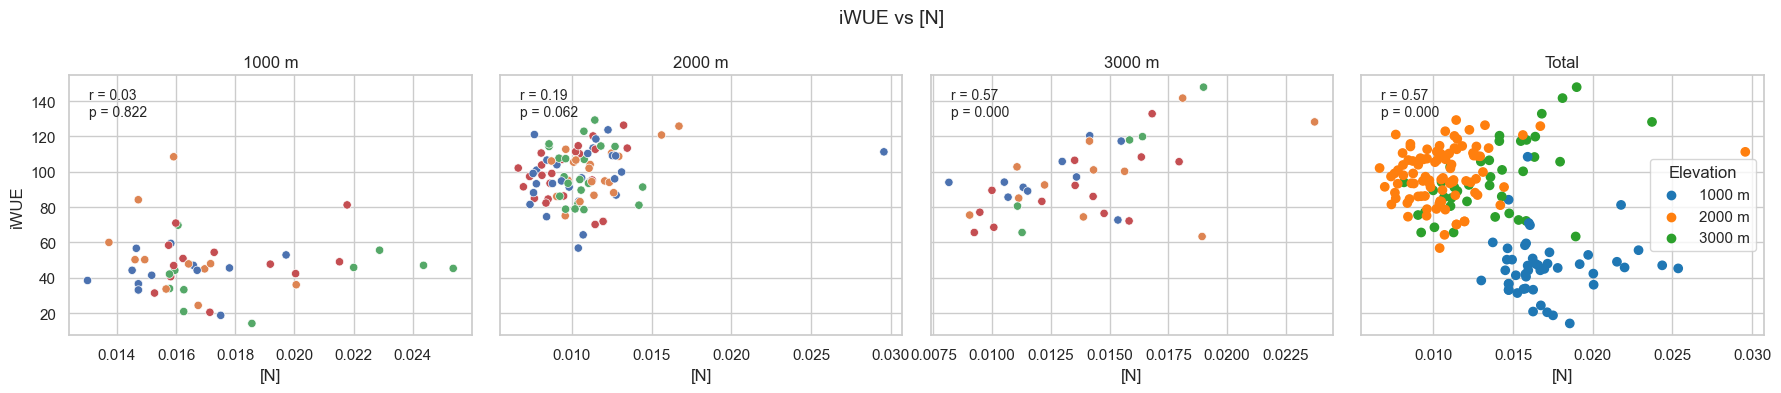

In [48]:
traits = [thick,though,LA,SLA,leaf_water,'dry matter content (mg/g)',"Carea","Narea","[N]"]

elevations = [1000, 2000, 3000]
from scipy.stats import pearsonr

df = data
for trait in traits:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    # Elevation-specific plots
    for ax, elev in zip(axes[:3], elevations):
        subset = df[df['elevation_m'] == elev]
        sns.scatterplot(
        data=subset,
        x=trait,
        y=iWUE,
        hue="Sub",
        legend = False,
        ax=ax
        )
        ax.set_title(f'{elev} m')
        ax.set_xlabel(trait)
        ax.set_ylabel('iWUE')
        # Pearson correlation
        r, p = pearsonr(subset[trait], subset[iWUE])

       # annotation
        ax.text(
        0.05, 0.95,
        f"r = {r:.2f}\np = {p:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
        )

    ### Total dataset
    color_map = {
    1000: "tab:blue",
    2000: "tab:orange",
    3000: "tab:green"
    }

    colors = df["elevation_m"].map(color_map)
    axes[3].scatter(df[trait], df[iWUE],c=colors)
    axes[3].set_title('Total')
    axes[3].set_xlabel(trait)
    # annotation
    axes[3].text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p:.3f}",
    transform=axes[3].transAxes,
    ha="left",
    va="top",
    fontsize=10
    )

    # leyenda manual
    for elev, col in color_map.items():
     axes[3].scatter([], [], c=col, label=f"{elev} m")

     axes[3].legend(title="Elevation")

    # Pearson correlation
    r, p = pearsonr(df[trait], df[iWUE])

    

    plt.suptitle(f'iWUE vs {trait}', fontsize=14)
    plt.tight_layout()
    plt.show()


In [67]:

def create_boxplots(var,data, ax = None):
 import matplotlib.pyplot as plt
 import seaborn as sns
 import pandas as pd
 import matplotlib.patches as patches 


 # Simulación: tu código de melt y orden ya definido antes
 df_long = pd.melt(
    data,
    id_vars=["name", "Sub"],
    value_vars=[var],
    var_name="variable",
    value_name="valor"
  ) 

 # Orden de tratamiento y especies
 orden = ["C", "N", "P", "NP"]
 orden_sp = ["Weinmania  loxensis","Hedyosmun  purpurascens",
            "Myrcia sp nov","Alchornea lojaensis",
            "Pouteria torta","Clarisia  racemosa"]

 df_long["Sub"] = pd.Categorical(df_long["Sub"], categories=orden, ordered=True)
 df_long["name"] = pd.Categorical(df_long["name"], categories=orden_sp, ordered=True)

 # Asignar altitudes según el orden de especies
 altitud_map = {
    "Weinmania  loxensis": "3000",
    "Hedyosmun  purpurascens": "3000",
    "Myrcia sp nov": "2000",
    "Alchornea lojaensis": "2000",
    "Pouteria torta": "1000",
    "Clarisia  racemosa": "1000"
 }
 df_long["altitud"] = df_long["name"].map(altitud_map)

 # Colores fijos por especie
 palette_species = {
    "Weinmania  loxensis": "#1b9e77",
    "Hedyosmun  purpurascens": "#d95f02",
    "Myrcia sp nov": "#7570b3",
    "Alchornea lojaensis": "#e7298a",
    "Pouteria torta": "#66a61e",
    "Clarisia  racemosa": "#e6ab02"
 }

 # Estilo
 sns.set(style="whitegrid")

 # Figura tamaño A4 reducido
 #figsize_a4 = (5.27, 5.69)

 # Forzar el orden correcto de las altitudes
 orden_alt = ["1000", "2000", "3000"]
 df_long["altitud"] = pd.Categorical(df_long["altitud"], categories=orden_alt, ordered=True)

 g = sns.FacetGrid(
    df_long,
    row="variable",
    col="altitud",
    sharey=True,
    height=3,
    aspect=1,
    margin_titles=True
 )

 # Boxplot por especie
 g.map_dataframe(
    sns.boxplot,
    x="Sub", y="valor", hue="name",
    linewidth=1, palette=palette_species, dodge=True
 )

 # Swarmplot con mismo color
 g.map_dataframe(
    sns.swarmplot,
    x="Sub", y="valor", hue="name",
    palette=palette_species, alpha=0.5, dodge=True
 )

 for ax, (_, subdata) in zip(g.axes.flat, g.facet_data()):
    if subdata is None or subdata.empty:
        continue
    
    # Cálculo por especie dentro del panel
    for sp in subdata["name"].unique():
        
        # Filtrar datos de la especie y del tratamiento control
        mean_val = subdata[
            (subdata["name"] == sp) & 
            (subdata["Sub"] == "C")
        ]["valor"].mean()
        
        if pd.isna(mean_val):
            continue
        
        # Línea horizontal con color fijo del tratamiento CONTROL
        ax.axhline(
            y=mean_val,
            color="#454747",   # o el color que quieras para C
            linestyle="--",
            linewidth=1
        )


 # Etiquetas
 g.set_axis_labels(" ", "")
 g.set_titles(row_template="{row_name}", col_template="{col_name} m")

 # Ajustar figura
 #g.fig.set_size_inches(figsize_a4)
 g.fig.subplots_adjust(wspace=0.05, hspace=0.3)

 # --- Dibujar cajas de altitud ---
 # Como ahora el orden es fijo, podemos agrupar fácilmente
 altitud_groups = {
    "1000 m": [0],
    "2000 m": [1],
    "3000 m": [2]
 }

 for alt_label, indices in altitud_groups.items():
    for idx in indices:
        ax = g.axes[0][idx]
        ax.add_patch(
            patches.Rectangle(
                (-0.5, ax.get_ylim()[0]),
                len(orden),
                ax.get_ylim()[1] - ax.get_ylim()[0],
                fill=False, lw=2, edgecolor="red", alpha=0.5
            )
        )
 
 return g.fig
 

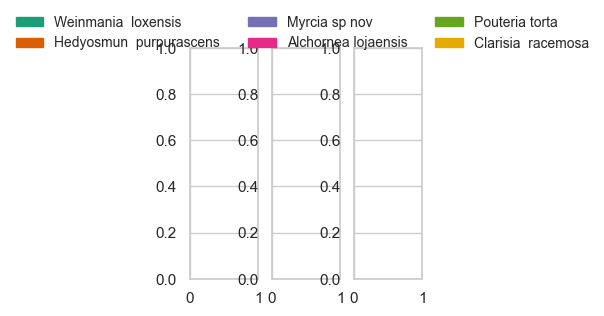

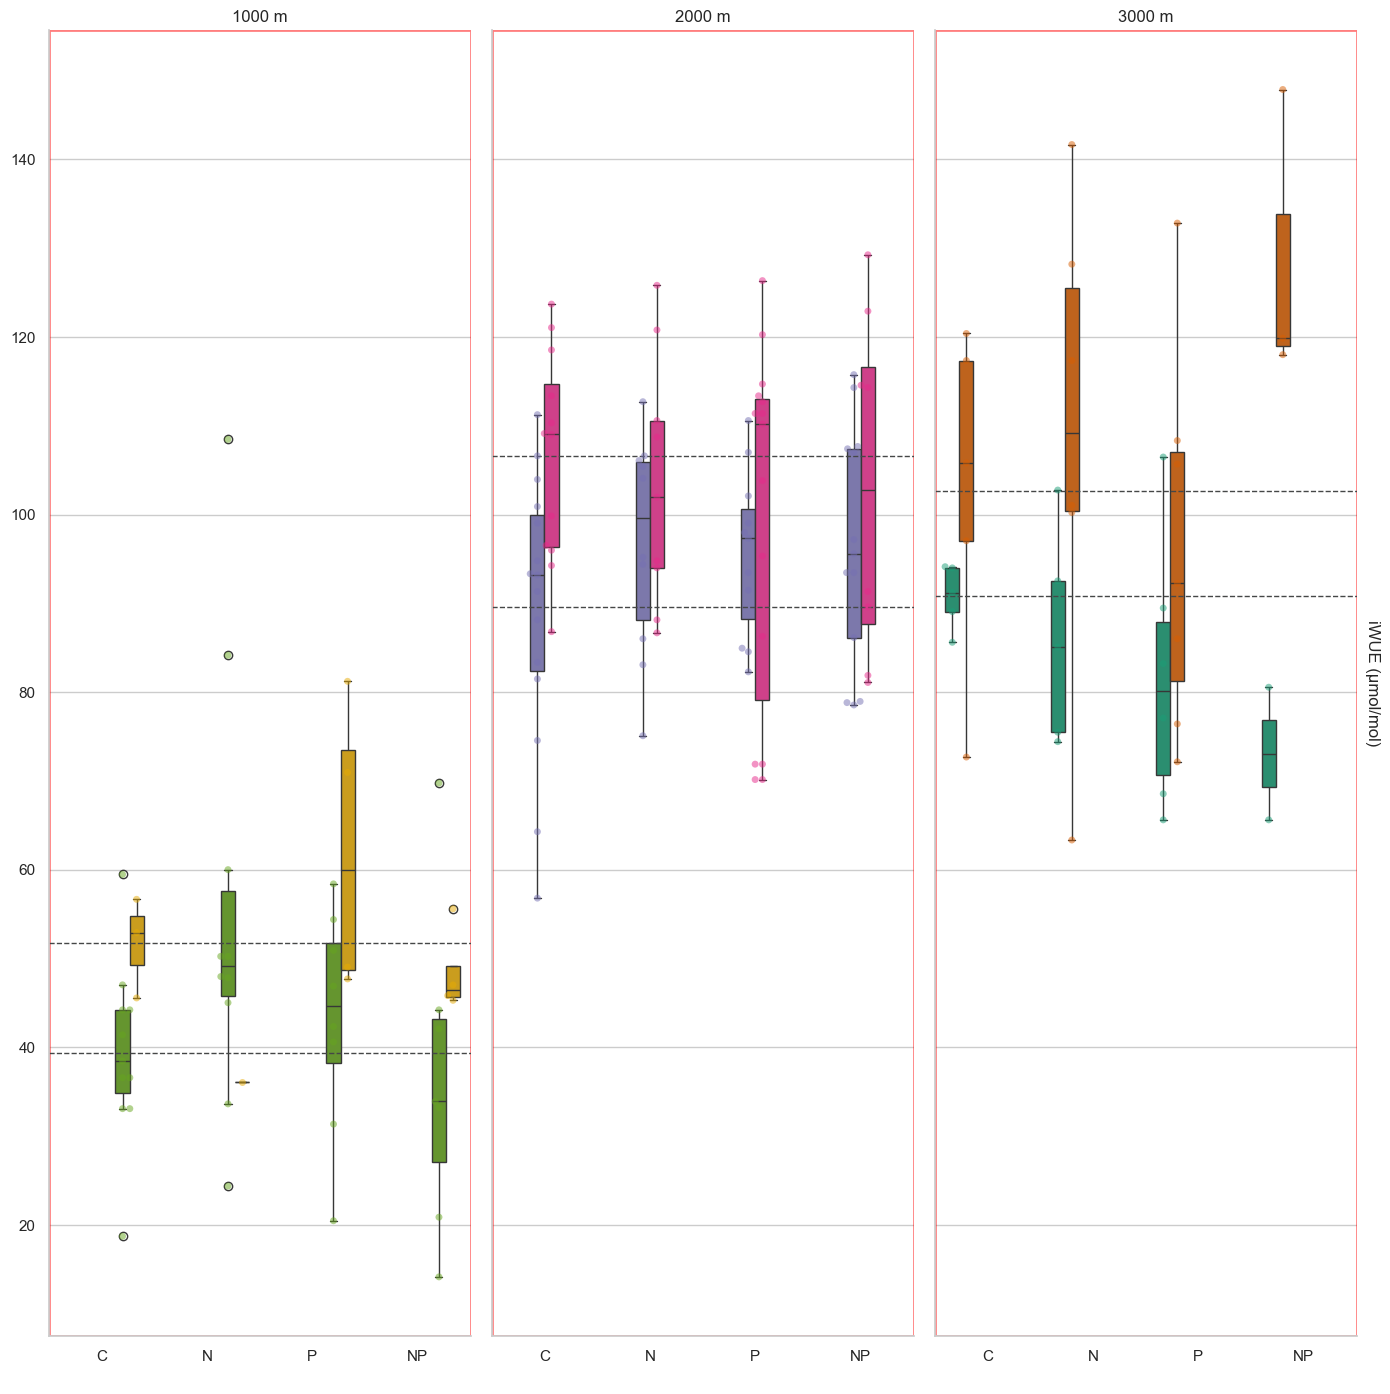

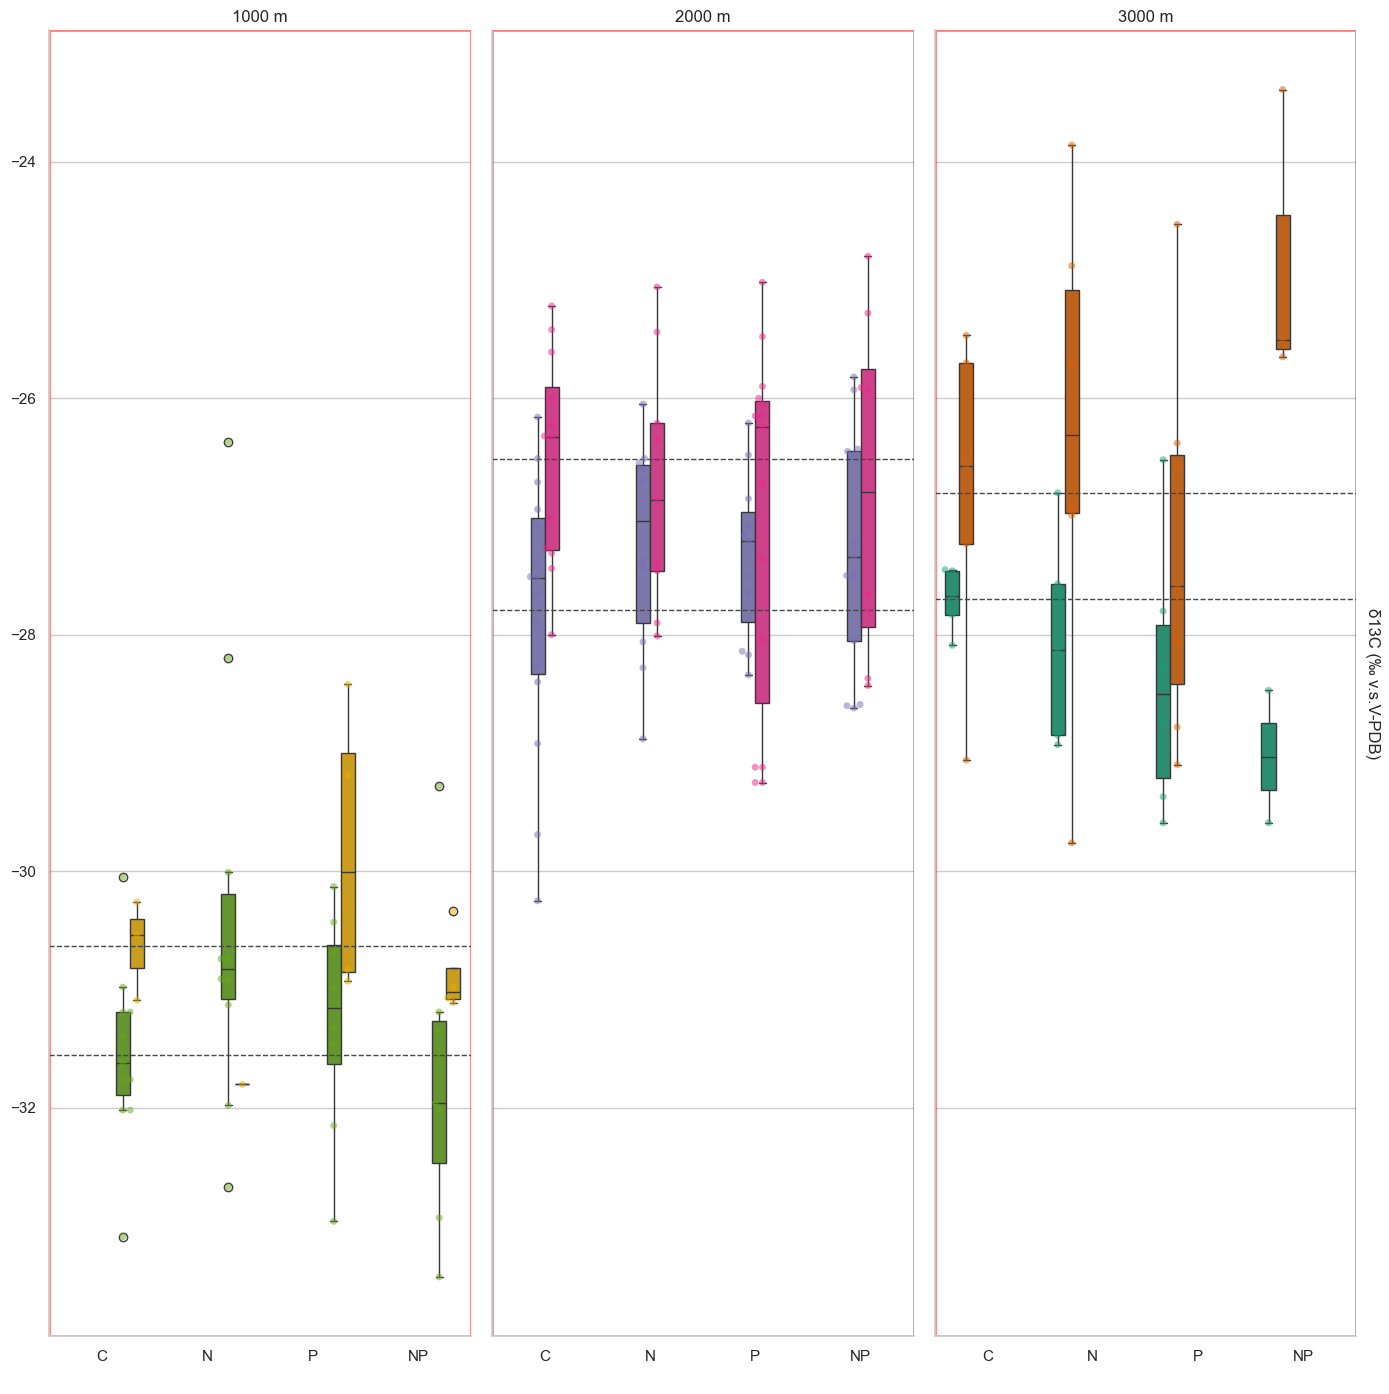

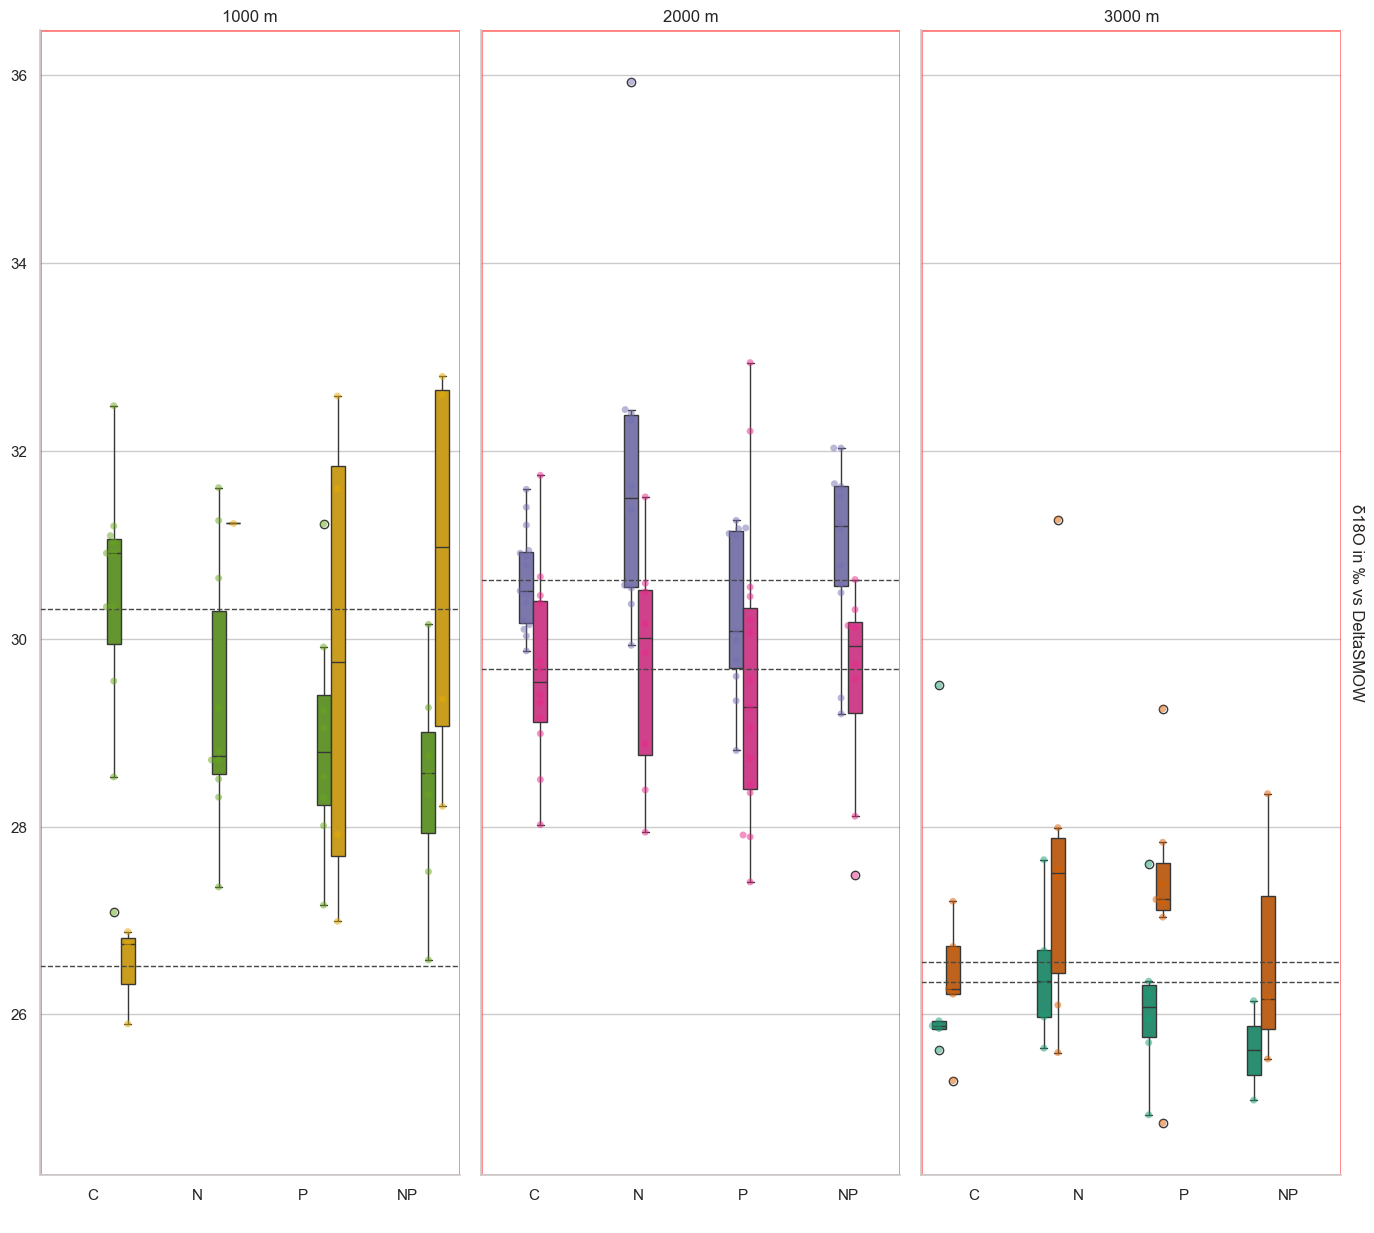

In [68]:
import matplotlib.pyplot as plt
import numpy as np

### HELP on the per elevation plots

variables_isotopos = [iWUE, named13C_cellulose, name18O] 
# variables = [vb1, vb2, vb3, vb4] # Bulk 
# variables = [vf1, vf2] #HELP: rasgos 

def graph(variables):
 """This functions creates the final plot with the thin boxplots and lines of the control"""
 # Crear figura principal
 fig, axes = plt.subplots(1, 3, figsize=(3, 3))# el cuadro vacio que me sale al inicio
 axes = axes.flatten()

 # --- Paleta y etiquetas de especie (las mismas que usas en create_boxplots)
 palette_species = {
    "Weinmania  loxensis": "#1b9e77",
    "Hedyosmun  purpurascens": "#d95f02",
    "Myrcia sp nov": "#7570b3",
    "Alchornea lojaensis": "#e7298a",
    "Pouteria torta": "#66a61e",
    "Clarisia  racemosa": "#e6ab02"
 }
 orden_sp = list(palette_species.keys())

 # --- Loop sobre variables ---
 for i, var in enumerate(variables):
    fig_sub = create_boxplots(var, data)   # tu función modificada para devolver la figura
    fig_sub.set_size_inches(15, 20)

    # Mostrar la imagen en el grid
    #axes[i].imshow(fig_sub)
    #axes[i].axis("off")
    #axes[i].set_title(var, fontsize=12, fontweight="bold")

    #plt.close(fig_sub)  # cerrar la subfigura individual

 # --- Eliminar paneles vacíos ---
 for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

 # --- Crear leyenda global (una vez) ---
 import matplotlib.patches as mpatches
 handles = [mpatches.Patch(color=palette_species[sp], label=sp) for sp in orden_sp]
 
 fig.legend(
    handles=handles,
    loc='upper center', bbox_to_anchor=(0.5, 1.03),
    ncol=3, frameon=False, fontsize=10
 )

 #plt.tight_layout(rect=[0, 0.5, 0.5, 0.95])  # deja espacio para la leyenda
 return plt.show()

graph(variables_isotopos)

In [ ]:
#ar_traits = [vf1,vf2,vf3]
#graph(var_traits)

# Aunque puede servir para ver ciertas tendencias no me gustas mucho el grafico porque no se aprecia de uno en 1. Mejor los boxplots de abajo.

In [ ]:
import create_boxplots_control
%run create_boxplots_control.py

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

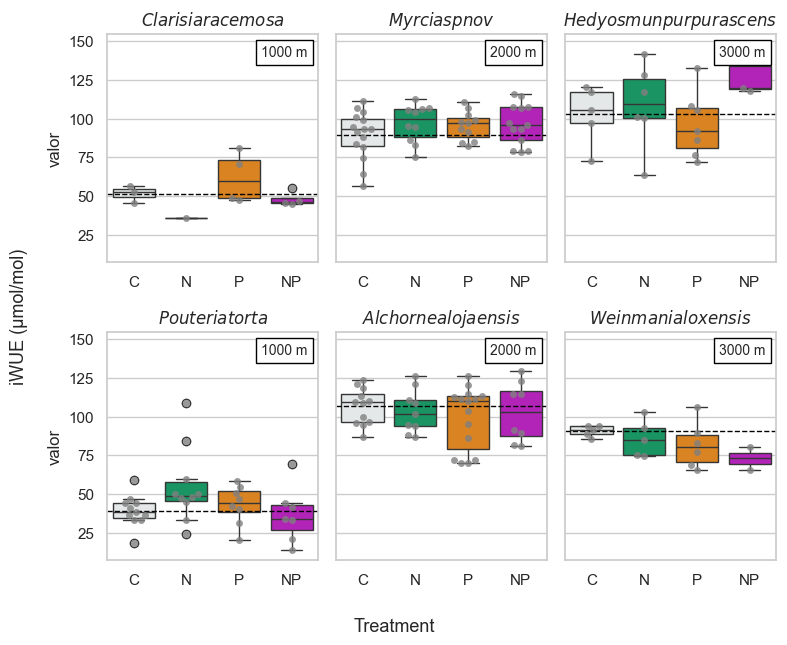

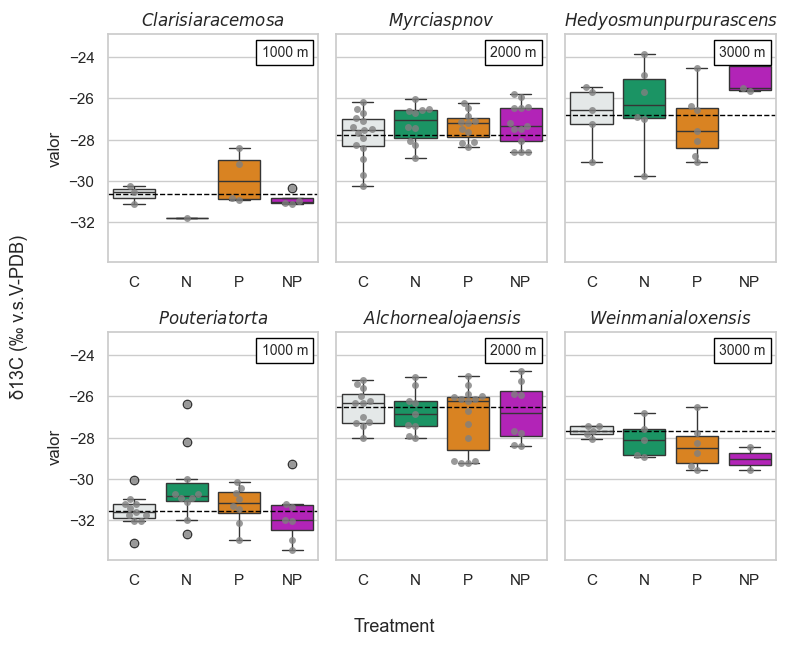

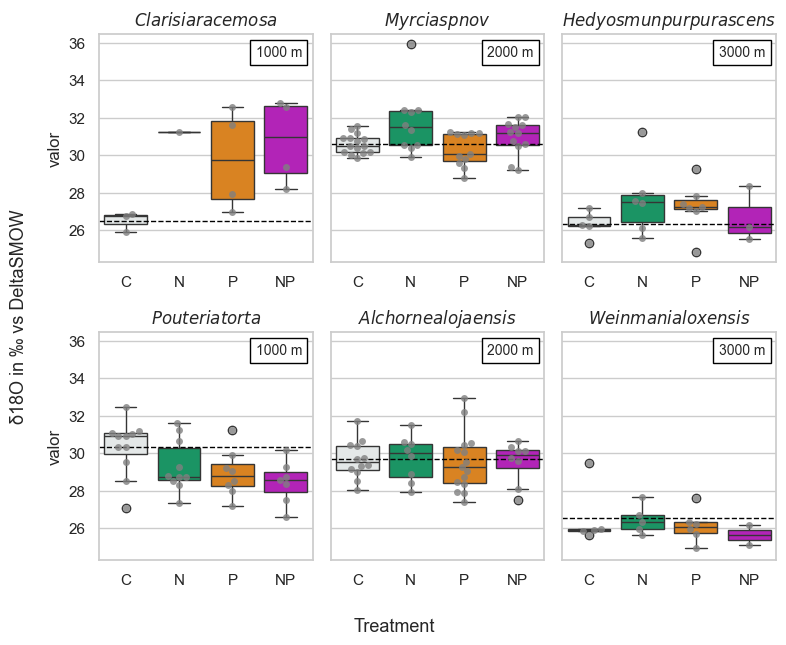

In [ ]:
isotopos = variables_isotopos
for variable in isotopos: 
 create_boxplots_control(variable,data)

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

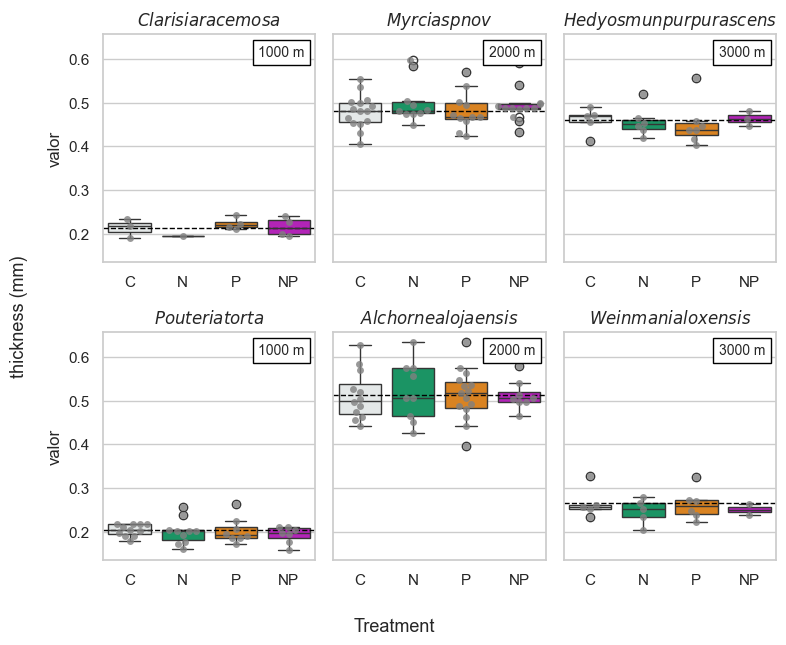

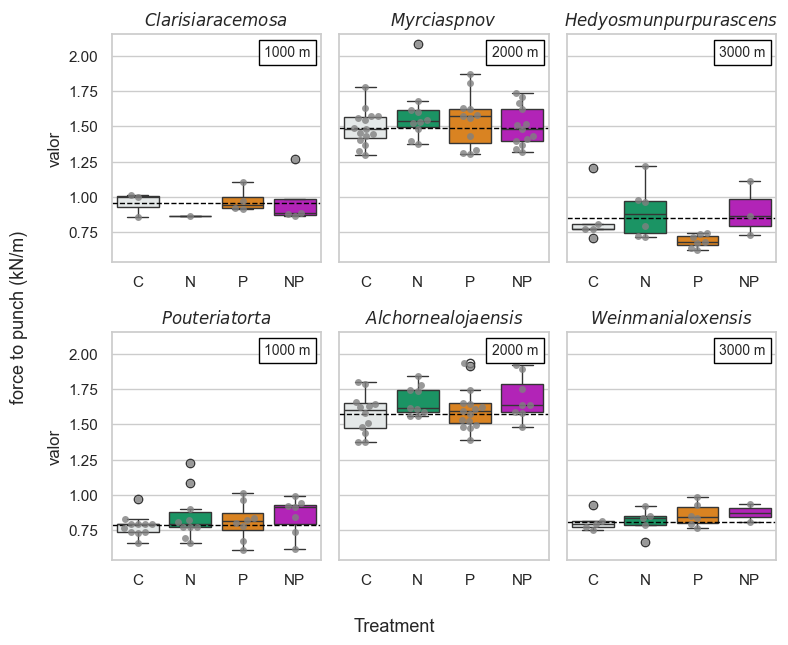

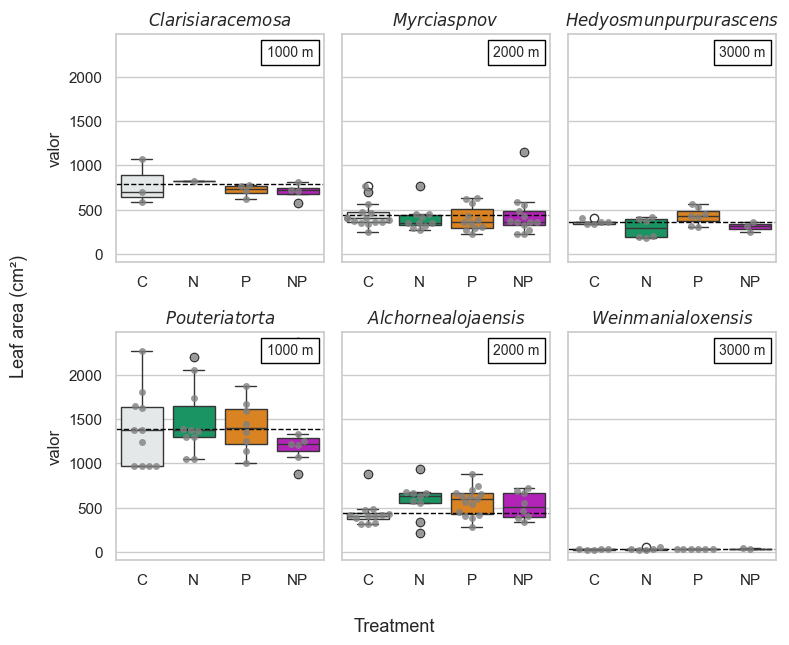

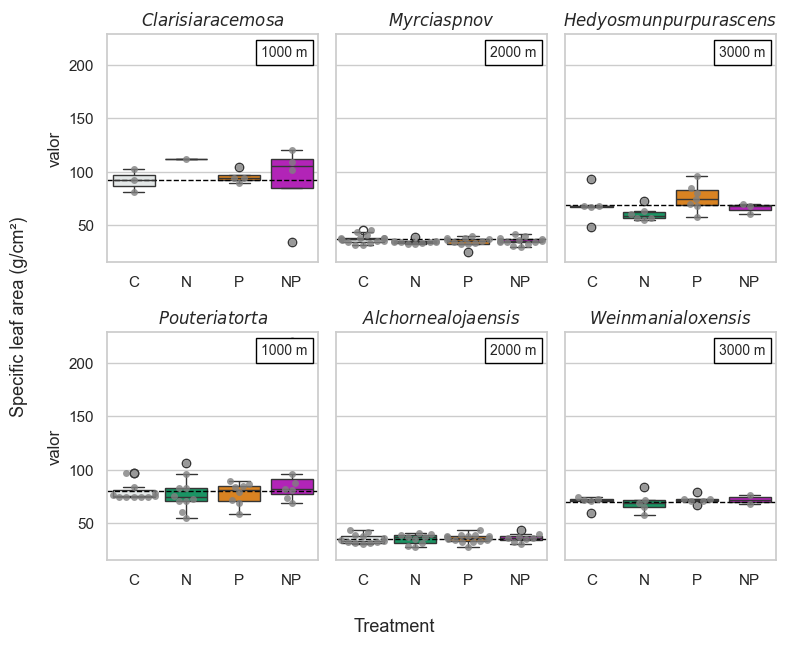

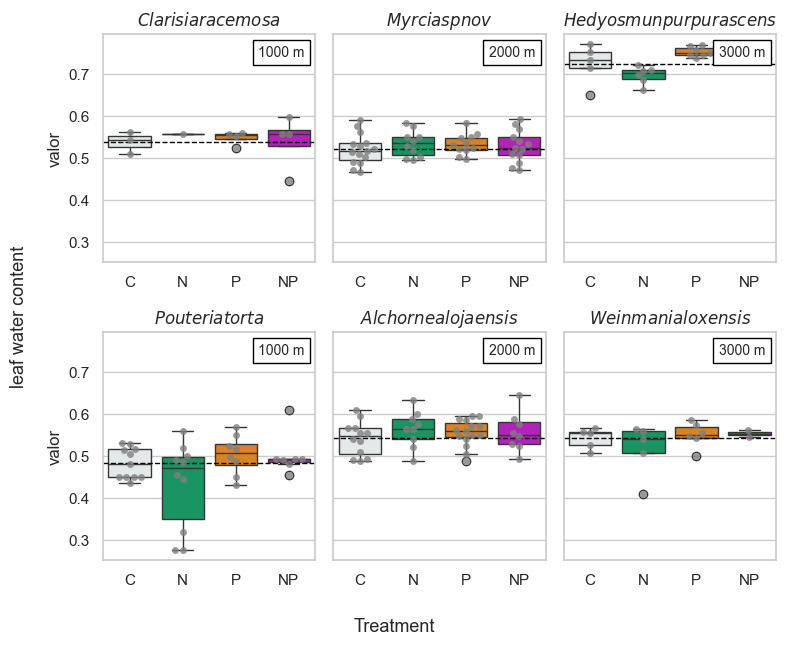

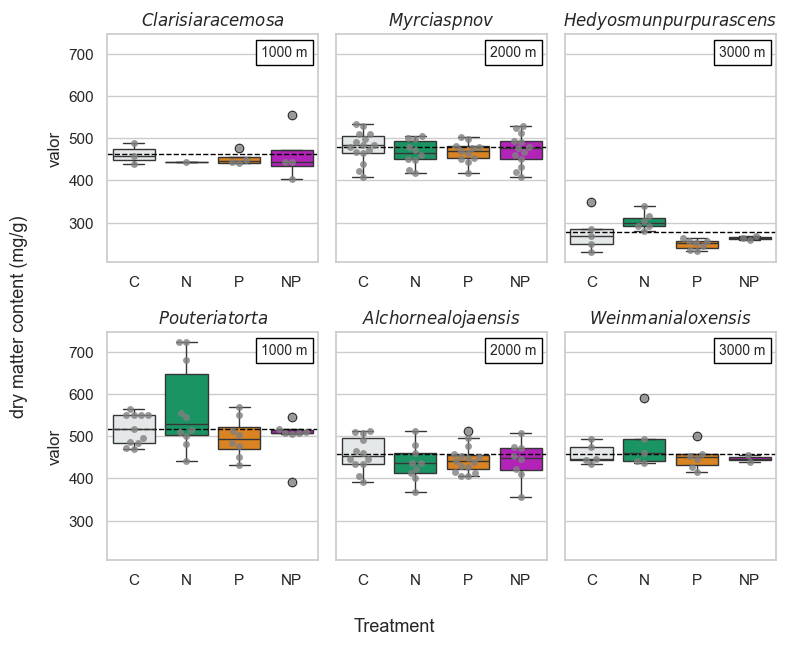

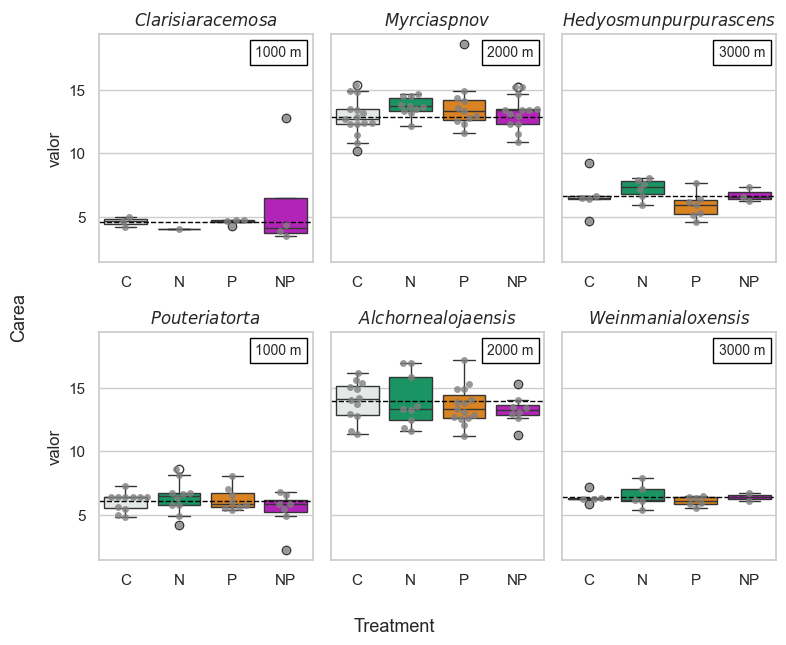

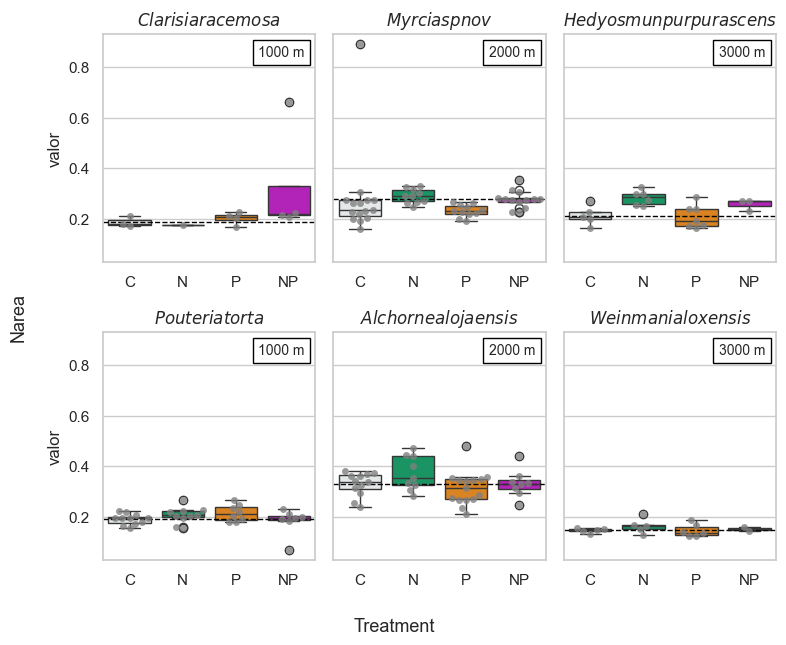

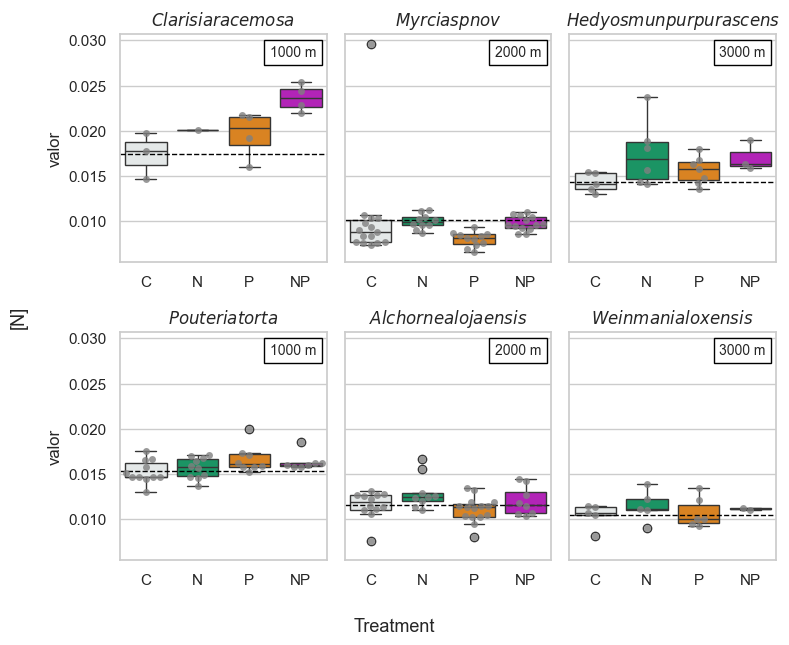

In [ ]:
variables = traits
for variable in variables:

 create_boxplots_control(variable,data)

In [ ]:
%run kruskal_por_especie_y_tratamiento.py

kruskal_por_especie_y_tratamiento(data, variable=var)


Comparacion entre tratamientos
δ15N (‰ v.s.AIR)

TEST KRUSKALL

Especie: Weinmania  loxensis
H = 3.090, p = 0.3779, df = 3

TEST ANOVA DE UNA VIA

Especie: Weinmania  loxensis
F-statistic: 1.287001573491615
P-value: 0.31744477470322563
Comparacion entre tratamientos
δ15N (‰ v.s.AIR)

TEST KRUSKALL

Especie: Pouteria torta
H = 2.721, p = 0.4366, df = 3

TEST ANOVA DE UNA VIA

Especie: Pouteria torta
F-statistic: 1.0166940135619393
P-value: 0.3981558799696058
Comparacion entre tratamientos
δ15N (‰ v.s.AIR)

TEST KRUSKALL

Especie: Hedyosmun  purpurascens
H = 1.457, p = 0.6922, df = 3

TEST ANOVA DE UNA VIA

Especie: Hedyosmun  purpurascens
F-statistic: 0.8398045789570674
P-value: 0.4906641498754064
Comparacion entre tratamientos
δ15N (‰ v.s.AIR)

TEST KRUSKALL

Especie: Clarisia  racemosa
H = 6.558, p = 0.0874, df = 3

TEST ANOVA DE UNA VIA

Especie: Clarisia  racemosa
F-statistic: 4.532075855451945
P-value: 0.038836636205850025
Comparacion entre tratamientos
δ15N (‰ v.s.AIR)

TEST KRUSK

[{'especie': 'Weinmania  loxensis',
  'H': 3.0900584795321677,
  'p': 0.3779472787561688,
  'df': 3},
 {'especie': 'Pouteria torta',
  'H': 2.721336105904409,
  'p': 0.43661361542902744,
  'df': 3},
 {'especie': 'Hedyosmun  purpurascens',
  'H': 1.457254246727939,
  'p': 0.6921705738844578,
  'df': 3},
 {'especie': 'Clarisia  racemosa',
  'H': 6.557692307692314,
  'p': 0.08741481945579616,
  'df': 3},
 {'especie': 'Myrcia sp nov',
  'H': 29.043943676194765,
  'p': 2.192316418590188e-06,
  'df': 3},
 {'especie': 'Alchornea lojaensis',
  'H': 29.441588682395338,
  'p': 1.8085259456153285e-06,
  'df': 3}]

# modelos

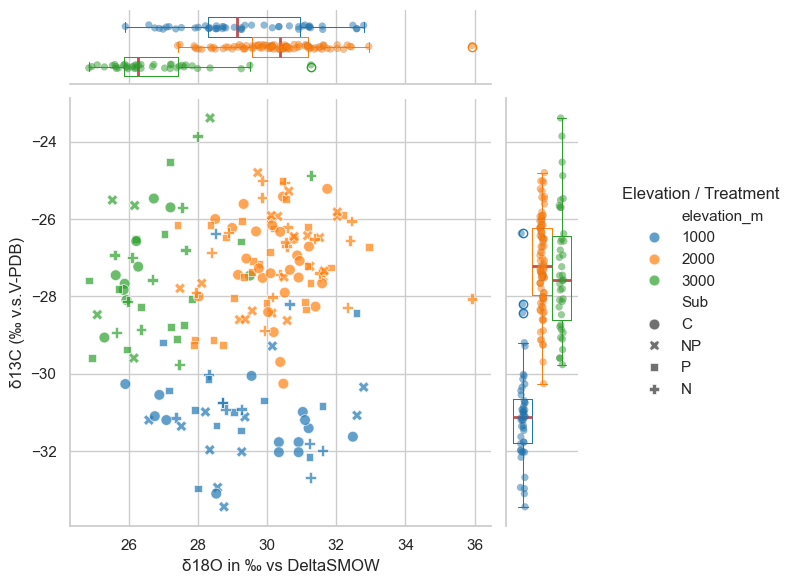

In [ ]:
g = sns.JointGrid(data=data, x=vp4, y=vp3, hue="elevation_m", palette="tab10")
g.plot_joint(sns.scatterplot, data=data,          # 👈 CLAVE
    style="Sub",        # o "name" si ese es tu factor
    s=60,
    alpha=0.7)
g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5)
g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2})
g.ax_joint.legend_.remove()
# ── LEYENDA FUERA ───────────────────────────────
handles, labels = g.ax_joint.get_legend_handles_labels()
# crear leyenda externa
g.fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Elevation / Treatment"
)

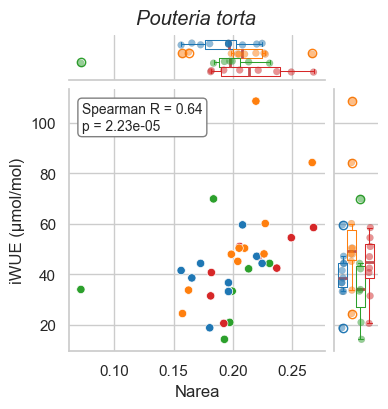

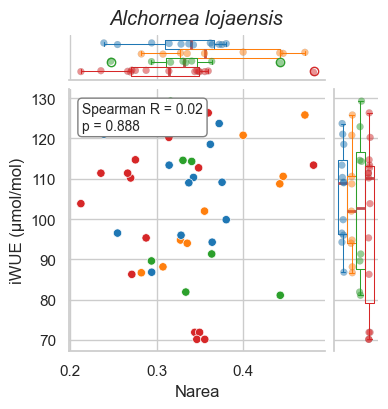

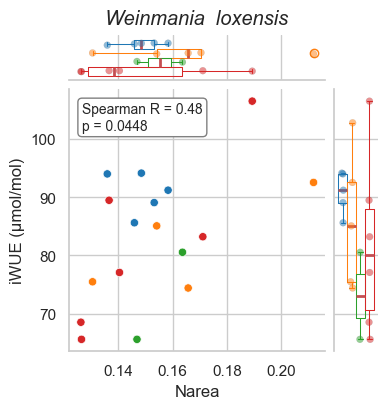

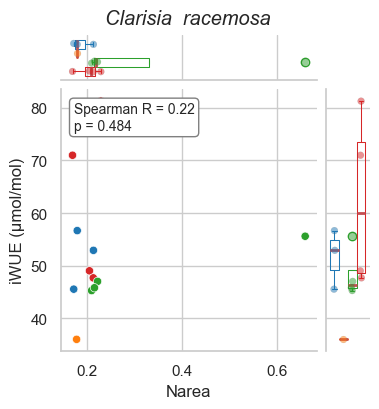

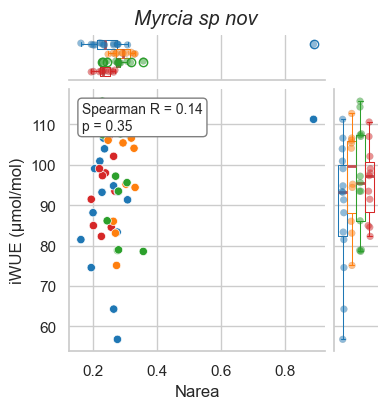

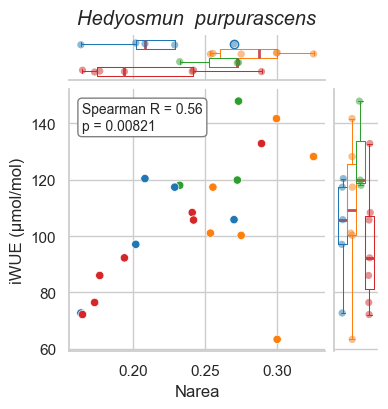

In [ ]:
#Not useful
from scipy.stats import spearmanr

especies = ["Pouteria torta",
  "Alchornea lojaensis",
  "Weinmania  loxensis",
  "Clarisia  racemosa",
  "Myrcia sp nov",
  "Hedyosmun  purpurascens"] #creamos vector especies 
for especie in especies:
    df_name = "df_"+especie
    df_name = data[data["name"]== especie]
    # Spearman (global, sin separar por Sub)
    rho, pval = spearmanr(df_name["Narea"], df_name[iWUE], nan_policy="omit")

    g = sns.JointGrid(data=df_name, x= "Narea", y=iWUE, hue="Sub", palette="tab10",height=4)
    g.plot_joint(sns.scatterplot, legend=False)
    g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5, legend=False)
    g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2},legend=False)
    
    # 📌 Anotación Spearman
    g.ax_joint.annotate(
        f"Spearman R = {rho:.2f}\np = {pval:.3g}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", fc="white", ec="gray")
    )
   
    g.fig.suptitle(especie, y=1.02, style="italic") #

    


### No usar pero crea los codigos en relacion delta 13/ d18O

especies = ["Pouteria torta",
  "Alchornea lojaensis",
  "Weinmania  loxensis",
  "Clarisia  racemosa",
  "Myrcia sp nov",
  "Hedyosmun  purpurascens"] #creamos vector especies 
for especie in especies:
    df_name = "df_"+especie
    df_name = data[data["name"]== especie]
    g = sns.JointGrid(data=df_name, x=vp4, y=vp3, hue="Sub", palette="tab10",height=4)
    g.plot_joint(sns.scatterplot, legend=False)
    g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5, legend=False)
    g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2},legend=False)
    
    g.ax_joint.set_xlim(22, 36)
    g.ax_joint.set_ylim(-22, -36 )
    g.ax_marg_x.set_xlim(25 ,36)
    #g.ax_marg_y.set_ylim(-22, -35)
    mean_x= df_name[df_name["Sub"]=="C"][vp4].mean() 
    mean_y= df_name[df_name["Sub"]=="C"][vp3].mean() 
    g.refline(x=mean_x, y=mean_y) #means of the control
    g.fig.suptitle(especie, y=1.02, style="italic") #

    

| **Pattern**                          | **Interpretation**                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------------- |
| Both δ¹³C and δ¹⁸O increase          | Likely due to **reduced stomatal conductance** → both iWUE and leaf water δ¹⁸O increase.    |
| δ¹³C increases but δ¹⁸O does not     | Possibly due to **increased photosynthesis**, not stomatal closure.                         |
| δ¹³C does not increase but δ¹⁸O does | Could indicate **stomatal closure**, but photosynthesis also dropped → no iWUE gain.        |
| No correlation                       | Suggests other processes dominate (e.g., environmental noise, post-photosynthetic effects). |
